# Loop Engineering — Hands-On Demo

> Reference: Addy Osmani, [Loop Engineering](https://addyosmani.com/blog/loop-engineering/)
> Theory guide: [loop_engineering.md](loop_engineering.md)

This notebook makes each of the 6 loop components **concrete and runnable** using Python.
Rather than describing the patterns abstractly, we build minimal working implementations
of each component so you understand *exactly* what needs to happen at each layer.

| Component | Demo |
|---|---|
| **Automations** | `LoopScheduler` — run tasks on a trigger condition |
| **Worktrees** | `WorktreeManager` — git worktree lifecycle |
| **Skills** | `SkillLoader` — read/validate SKILL.md files |
| **Sub-agents** | `DualAgentVerifier` — writer + reviewer pattern |
| **Persistent State** | `LoopMemory` — JSON state that survives restarts |
| **Complete loop** | `EngineeringLoop` — all components wired together |


In [1]:
import json
import subprocess
import tempfile
import textwrap
import time
import threading
from dataclasses import dataclass, field, asdict
from datetime import datetime
from pathlib import Path
from typing import Callable, Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("All imports OK")


All imports OK


## 1. Automations — The Heartbeat

An automation is a **trigger → context → decision → action** pipeline that runs
without human initiation.

In Claude Code this maps to `/loop` (recurring) or `/goal` (run-until-condition).
Here we build the equivalent in Python to make the pattern crystal clear.

### Key design rules
1. Every automation needs an **exit condition** — otherwise it runs forever.
2. Automations should be **idempotent** — re-running them should produce the same
   end state, not duplicate work.
3. Failures should **escalate to human**, not silently fail.


In [2]:
class LoopScheduler:
    """
    Minimal loop scheduler: runs a task function on a condition or schedule.

    Mirrors Claude Code's /goal concept:
      run task() until stop_condition() returns True, with max_iterations guard.
    """

    def __init__(self, task: Callable, stop_condition: Callable[[], bool],
                 max_iterations: int = 20, interval_sec: float = 0.0):
        self.task            = task
        self.stop_condition  = stop_condition
        self.max_iterations  = max_iterations
        self.interval_sec    = interval_sec
        self.history: list   = []

    def run(self, verbose: bool = True) -> dict:
        start = time.time()
        for i in range(self.max_iterations):
            result = self.task(iteration=i)
            self.history.append({'iteration': i, 'result': result,
                                  'ts': datetime.now().isoformat()})
            if verbose:
                print(f"  [iter {i:02d}] {result}")

            if self.stop_condition():
                status = 'completed'
                break
            if self.interval_sec > 0:
                time.sleep(self.interval_sec)
        else:
            status = 'max_iterations_reached'  # ← escalation trigger

        return {'status': status, 'iterations': len(self.history),
                'elapsed_sec': round(time.time() - start, 2)}


# ── Example: CI triage automation ────────────────────────────────────────────
# Simulate: automation checks whether all CI jobs pass.
# Runs until they do (or max iterations reached → escalate).

ci_state = {'passing': False, 'check_count': 0, 'fixed_at': 3}

def ci_triage_task(iteration: int) -> str:
    ci_state['check_count'] += 1
    # Simulate: CI starts failing, then gets fixed at iteration 3
    if iteration >= ci_state['fixed_at']:
        ci_state['passing'] = True
        return "CI: all jobs passing ✓"
    return f"CI: {2 - iteration} failing job(s) — writing to triage log"

def ci_is_green() -> bool:
    return ci_state['passing']

scheduler = LoopScheduler(
    task=ci_triage_task,
    stop_condition=ci_is_green,
    max_iterations=10,
)
result = scheduler.run()
print(f"\nLoop result: {result}")
print("Idempotency check: re-running on already-green CI →")
result2 = scheduler.run(verbose=False)
print(f"  {result2}  (should complete in 1 iteration)")


  [iter 00] CI: 2 failing job(s) — writing to triage log
  [iter 01] CI: 1 failing job(s) — writing to triage log
  [iter 02] CI: 0 failing job(s) — writing to triage log
  [iter 03] CI: all jobs passing ✓

Loop result: {'status': 'completed', 'iterations': 4, 'elapsed_sec': 0.0}
Idempotency check: re-running on already-green CI →
  {'status': 'completed', 'iterations': 5, 'elapsed_sec': 0.0}  (should complete in 1 iteration)


## 2. Worktrees — Parallel Isolation

Without worktrees, two agents editing the same directory corrupt each other's changes.
`git worktree` creates a **separate working directory** on a new branch, sharing the
same repo object store.

```bash
git worktree add ../task-auth feature/auth-refactor
git worktree add ../task-perf feature/perf-cache
git worktree list
# → main repo + 2 isolated task dirs; agents work in parallel without conflicts
git worktree remove ../task-auth   # clean up when done
```

The `WorktreeManager` below wraps this lifecycle.


In [3]:
class WorktreeManager:
    """
    Manages git worktrees for isolated agent tasks.

    In Claude Code, Agent tool calls with isolation='worktree' do this automatically.
    This class makes the underlying git mechanics explicit.
    """

    def __init__(self, repo_path: str = '.'):
        self.repo = Path(repo_path).resolve()
        self._worktrees: dict[str, Path] = {}

    def add(self, branch: str, base: str = 'HEAD') -> Path:
        """Create a worktree on a new branch, return its path."""
        wt_path = self.repo.parent / f'worktree-{branch.replace("/", "-")}'
        subprocess.run(
            ['git', 'worktree', 'add', '-b', branch, str(wt_path), base],
            cwd=self.repo, capture_output=True, check=True
        )
        self._worktrees[branch] = wt_path
        return wt_path

    def remove(self, branch: str) -> None:
        """Remove worktree and prune the reference."""
        path = self._worktrees.pop(branch, None)
        if path:
            subprocess.run(['git', 'worktree', 'remove', '--force', str(path)],
                           cwd=self.repo, capture_output=True)
            subprocess.run(['git', 'worktree', 'prune'], cwd=self.repo, capture_output=True)

    def list(self) -> list[dict]:
        """Return current worktrees from git."""
        out = subprocess.run(['git', 'worktree', 'list', '--porcelain'],
                             cwd=self.repo, capture_output=True, text=True)
        trees, cur = [], {}
        for line in out.stdout.splitlines():
            if line.startswith('worktree'):
                if cur: trees.append(cur)
                cur = {'path': line.split(' ', 1)[1]}
            elif line.startswith('branch'):
                cur['branch'] = line.split(' ', 1)[1]
        if cur: trees.append(cur)
        return trees

    def __enter__(self): return self
    def __exit__(self, *args):
        for branch in list(self._worktrees):
            self.remove(branch)


# ── Demonstrate worktree isolation ────────────────────────────────────────────
# Use a temp git repo so this cell is self-contained
with tempfile.TemporaryDirectory() as tmpdir:
    repo = Path(tmpdir) / 'demo-repo'
    repo.mkdir()
    subprocess.run(['git', 'init'], cwd=repo, capture_output=True)
    subprocess.run(['git', 'config', 'user.email', 'demo@example.com'], cwd=repo, capture_output=True)
    subprocess.run(['git', 'config', 'user.name', 'Demo'], cwd=repo, capture_output=True)
    (repo / 'README.md').write_text('# Demo repo\n')
    subprocess.run(['git', 'add', '.'], cwd=repo, capture_output=True)
    subprocess.run(['git', 'commit', '-m', 'init'], cwd=repo, capture_output=True)

    mgr = WorktreeManager(repo)

    # Spawn two isolated worktrees for two parallel agent tasks
    wt_auth = mgr.add('feature/auth-refactor')
    wt_perf = mgr.add('feature/perf-cache')

    # Each agent writes to its own branch — zero conflict
    (wt_auth / 'auth.py').write_text('# auth implementation\n')
    (wt_perf / 'cache.py').write_text('# cache implementation\n')

    print("Worktrees created:")
    for wt in mgr.list():
        print(f"  {wt.get('branch', 'main'):35s}  →  {wt['path']}")

    print(f"\nAgent A (auth) files:  {[f.name for f in wt_auth.iterdir()]}")
    print(f"Agent B (perf) files:  {[f.name for f in wt_perf.iterdir()]}")
    print(f"Main repo files:       {[f.name for f in repo.iterdir() if not f.name.startswith('.')]}")
    print("\nNo overlap — agents can't corrupt each other's work.")

    mgr.remove('feature/auth-refactor')
    mgr.remove('feature/perf-cache')
    print("\nWorktrees cleaned up.")


Worktrees created:
  refs/heads/master                    →  /tmp/tmp3idxlnbi/demo-repo
  refs/heads/feature/auth-refactor     →  /tmp/tmp3idxlnbi/worktree-feature-auth-refactor
  refs/heads/feature/perf-cache        →  /tmp/tmp3idxlnbi/worktree-feature-perf-cache

Agent A (auth) files:  ['auth.py', 'README.md', '.git']
Agent B (perf) files:  ['README.md', '.git', 'cache.py']
Main repo files:       ['README.md']

No overlap — agents can't corrupt each other's work.

Worktrees cleaned up.


## 3. Skills — Embedded Knowledge

A **Skill** is a markdown file that codifies what an agent needs to know about your
project without being told in every prompt. In Claude Code, `.claude/commands/*.md`
files become `/command-name` slash commands.

### What belongs in a skill
- Build / test / lint commands
- Which files / directories NOT to touch
- Code style rules and naming conventions
- Domain vocabulary specific to the project
- Escalation rules ("if X fails, stop and ask")

### What does NOT belong
- Implementation details that change frequently
- Secrets or credentials
- Things already enforced by linters / CI

The `SkillLoader` below shows how an agent would parse and validate a skill file.


In [4]:
EXAMPLE_SKILL_MD = """
---
name: python-project
description: Development conventions for a Python ML project
---

## Build & Test

```bash
uv run pytest tests/ -x -q        # run tests; stop on first failure
uv run ruff check .                # lint
uv run ruff format .               # format
```

## Do Not Touch

- `data/` — raw datasets; never commit large files here
- `models/pretrained/` — binary weights; tracked via DVC, not git
- `.env` — secrets; never read or modify

## Code Style

- Functions: `snake_case`, max 40 lines
- Classes: `PascalCase`
- Type hints required on all public functions
- No `print()` in library code — use `logging`

## Escalation Rules

- If tests fail after 2 fix attempts: stop, summarise findings, ask human
- If a migration touches > 5 tables: stop and ask for review
- Never push directly to `main`

## Domain Vocabulary

- `sample`: one training example (image + label)
- `sweep`: a hyperparameter search run
- `head`: the final classification layer
"""


@dataclass
class Skill:
    name: str
    description: str
    sections: dict[str, str]
    raw: str

class SkillLoader:
    """Parse and validate a SKILL.md file."""

    @staticmethod
    def load(content: str) -> Skill:
        lines = content.strip().splitlines()
        # Parse YAML-ish frontmatter (--- ... ---)
        name = description = ''
        body_start = 0
        if lines[0].strip() == '---':
            for i, line in enumerate(lines[1:], 1):
                if line.strip() == '---':
                    body_start = i + 1
                    break
                if line.startswith('name:'):
                    name = line.split(':', 1)[1].strip()
                elif line.startswith('description:'):
                    description = line.split(':', 1)[1].strip()

        # Parse sections (## headers)
        body = '\n'.join(lines[body_start:])
        sections = {}
        current_section = None
        buf = []
        for line in body.splitlines():
            if line.startswith('## '):
                if current_section:
                    sections[current_section] = '\n'.join(buf).strip()
                current_section = line[3:].strip()
                buf = []
            else:
                buf.append(line)
        if current_section:
            sections[current_section] = '\n'.join(buf).strip()

        return Skill(name=name, description=description, sections=sections, raw=content)

    @staticmethod
    def validate(skill: Skill) -> list[str]:
        """Return list of warnings for common skill anti-patterns."""
        warnings = []
        if 'Build & Test' not in skill.sections and 'Build' not in skill.sections:
            warnings.append("Missing 'Build & Test' section — agent won't know how to run tests")
        if 'Escalation Rules' not in skill.sections:
            warnings.append("Missing 'Escalation Rules' — loop may run indefinitely on failures")
        if 'Do Not Touch' not in skill.sections:
            warnings.append("No protected paths specified — agent may modify data or secrets")
        return warnings


skill = SkillLoader.load(EXAMPLE_SKILL_MD)
print(f"Skill: {skill.name!r}")
print(f"Desc:  {skill.description}")
print(f"Sections: {list(skill.sections.keys())}")

warnings = SkillLoader.validate(skill)
if warnings:
    print(f"\nWarnings: {warnings}")
else:
    print("\nValidation passed — skill is well-formed.")

print("\nBuild & Test commands extracted:")
for line in skill.sections.get('Build & Test', '').splitlines():
    if line.strip().startswith('uv run'):
        print(f"  {line.strip()}")


Skill: 'python-project'
Desc:  Development conventions for a Python ML project
Sections: ['Build & Test', 'Do Not Touch', 'Code Style', 'Escalation Rules', 'Domain Vocabulary']

Validation passed — skill is well-formed.

Build & Test commands extracted:
  uv run pytest tests/ -x -q        # run tests; stop on first failure
  uv run ruff check .                # lint
  uv run ruff format .               # format


## 4. Sub-agents — Distributed Verification

The core problem: **the model that wrote the code has strong priors that it is correct**.
It rationalises mistakes away when asked to self-review.

The fix: a **separate agent** with different instructions (and optionally a different model)
performs the review. It has no memory of the writing process, so it reads the code fresh.

```
Writer agent  →  draft implementation  →  Reviewer agent  →  approval / change requests
```

In Claude Code this maps to spawning an `Agent` tool call with:
- A different `prompt` (reviewer framing, not writer framing)
- Optionally a different `model` (Opus reviews Sonnet's output)
- `isolation: "worktree"` so it can't accidentally edit the draft


In [5]:
@dataclass
class AgentResult:
    agent_id: str
    role: str
    output: str
    approved: bool
    issues: list[str] = field(default_factory=list)

class DualAgentVerifier:
    """
    Simulates a Writer + Reviewer sub-agent pattern.

    In production: each 'agent' is a separate Agent tool call with isolated context.
    Here we simulate with two functions with different 'perspectives'.
    """

    def __init__(self, writer_fn: Callable, reviewer_fn: Callable):
        self.writer   = writer_fn
        self.reviewer = reviewer_fn

    def run(self, task: str) -> tuple[AgentResult, AgentResult]:
        # Agent A: write (no knowledge that a reviewer is coming)
        draft = self.writer(task)
        writer_result = AgentResult(
            agent_id='A', role='writer', output=draft, approved=True
        )
        # Agent B: review (no memory of writing the draft)
        review = self.reviewer(task, draft)
        reviewer_result = AgentResult(
            agent_id='B', role='reviewer',
            output=review['summary'],
            approved=review['approved'],
            issues=review['issues']
        )
        return writer_result, reviewer_result


# ── Simulation: agent A writes a function, agent B reviews it ─────────────────

def mock_writer(task: str) -> str:
    # Simulates writing code (with a deliberate bug for demo)
    return textwrap.dedent(f"""
        # Task: {task}
        def process_items(items):
            result = []
            for i in range(len(items)):     # ← style issue: use enumerate
                result.append(items[i] * 2)
            return result                   # ← missing: no handling for empty list
    """).strip()

def mock_reviewer(task: str, code: str) -> dict:
    # Simulates independent code review
    issues = []
    if 'range(len(' in code:
        issues.append("Use enumerate() instead of range(len())")
    if 'empty' not in code and 'if not' not in code:
        issues.append("No guard for empty input — what does the caller expect?")
    return {
        'summary': f"Reviewed {len(code.splitlines())} lines for task '{task}'",
        'approved': len(issues) == 0,
        'issues': issues
    }

verifier = DualAgentVerifier(mock_writer, mock_reviewer)
writer_r, reviewer_r = verifier.run("double all values in a list")

print("=== Writer Agent Output ===")
print(writer_r.output)
print()
print("=== Reviewer Agent Output ===")
print(f"Summary:  {reviewer_r.output}")
print(f"Approved: {reviewer_r.approved}")
print(f"Issues:   {reviewer_r.issues}")
print()
print("Key insight: the reviewer found issues the writer rationalised away.")
print("In production, Agent B has zero memory of Agent A's writing process.")


=== Writer Agent Output ===
# Task: double all values in a list
def process_items(items):
    result = []
    for i in range(len(items)):     # ← style issue: use enumerate
        result.append(items[i] * 2)
    return result                   # ← missing: no handling for empty list

=== Reviewer Agent Output ===
Summary:  Reviewed 6 lines for task 'double all values in a list'
Approved: False
Issues:   ['Use enumerate() instead of range(len())']

Key insight: the reviewer found issues the writer rationalised away.
In production, Agent B has zero memory of Agent A's writing process.


## 5. Persistent State — Memory Across Invocations

Agents forget everything between sessions. A loop that spans multiple runs needs
external state that **the repository remembers** even when the agent doesn't.

### The state pattern

```
Loop start → read state file → pick next task → execute → update state → loop end
↑                                                                              ↓
└──────────────────────────── next invocation ─────────────────────────────────┘
```

State should be:
- **Append-only log** (audit trail) + **current snapshot** (fast reads)
- Stored in the repo (version-controlled, PR-reviewable)
- Small: only facts not derivable from code/git


In [6]:
@dataclass
class Task:
    id: str
    title: str
    status: str = 'pending'      # pending | in_progress | done | escalated
    assigned_to: Optional[str] = None
    created_at: str = field(default_factory=lambda: datetime.now().isoformat())
    updated_at: str = field(default_factory=lambda: datetime.now().isoformat())
    notes: str = ''

class LoopMemory:
    """
    Persistent state manager for an engineering loop.
    Stores tasks in a JSON file; suitable for committing to the repo.
    """

    def __init__(self, state_path: str):
        self.path  = Path(state_path)
        self._log  = []
        if self.path.exists():
            data = json.loads(self.path.read_text())
            self._tasks = {t['id']: Task(**t) for t in data.get('tasks', [])}
            self._log   = data.get('log', [])
        else:
            self._tasks = {}

    # ── Task management ───────────────────────────────────────────────────────
    def add_task(self, task: Task) -> None:
        self._tasks[task.id] = task
        self._append_log('add', task.id, task.title)
        self._save()

    def update_status(self, task_id: str, status: str, notes: str = '') -> None:
        task = self._tasks[task_id]
        task.status     = status
        task.notes      = notes
        task.updated_at = datetime.now().isoformat()
        self._append_log('update', task_id, f'{status}: {notes}')
        self._save()

    def next_pending(self) -> Optional[Task]:
        return next((t for t in self._tasks.values() if t.status == 'pending'), None)

    def summary(self) -> dict:
        from collections import Counter
        counts = Counter(t.status for t in self._tasks.values())
        return dict(counts)

    # ── Internal ──────────────────────────────────────────────────────────────
    def _append_log(self, action: str, task_id: str, detail: str) -> None:
        self._log.append({'ts': datetime.now().isoformat(),
                          'action': action, 'task_id': task_id, 'detail': detail})

    def _save(self) -> None:
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self.path.write_text(json.dumps({
            'tasks': [asdict(t) for t in self._tasks.values()],
            'log':   self._log[-100:]  # keep last 100 entries
        }, indent=2))


# ── Demonstrate state survival across "sessions" ──────────────────────────────
with tempfile.TemporaryDirectory() as tmpdir:
    state_file = f'{tmpdir}/loop_state.json'

    # Session 1: loop discovers 3 tasks
    mem1 = LoopMemory(state_file)
    mem1.add_task(Task('t1', 'Fix failing test in auth module'))
    mem1.add_task(Task('t2', 'Update dependency: numpy 1.26 → 2.0'))
    mem1.add_task(Task('t3', 'Reduce CI time: matrix too large'))
    mem1.update_status('t1', 'in_progress', 'Agent A working in worktree-auth')
    print("Session 1 ended. State saved to disk.")
    print(f"Summary: {mem1.summary()}")

    # Session 2: new process, reads state from disk
    mem2 = LoopMemory(state_file)
    print(f"\nSession 2 started. Recovered: {mem2.summary()}")
    t = mem2.next_pending()
    print(f"Next task: {t.id} — {t.title!r}")
    mem2.update_status('t1', 'done', 'Fixed: mock was missing return value')
    mem2.update_status(t.id, 'in_progress', 'Agent B checking changelog')

    print(f"\nAfter Session 2: {mem2.summary()}")
    print(f"Audit log tail:")
    for entry in json.loads(Path(state_file).read_text())['log'][-3:]:
        print(f"  [{entry['ts'][:19]}] {entry['action']:6s} {entry['task_id']} — {entry['detail']}")


Session 1 ended. State saved to disk.
Summary: {'in_progress': 1, 'pending': 2}

Session 2 started. Recovered: {'in_progress': 1, 'pending': 2}
Next task: t2 — 'Update dependency: numpy 1.26 → 2.0'

After Session 2: {'done': 1, 'in_progress': 1, 'pending': 1}
Audit log tail:
  [2026-06-27T10:21:44] update t1 — in_progress: Agent A working in worktree-auth
  [2026-06-27T10:21:44] update t1 — done: Fixed: mock was missing return value
  [2026-06-27T10:21:44] update t2 — in_progress: Agent B checking changelog


## 6. Complete Loop — All Components Wired Together

This section assembles all five components into a single `EngineeringLoop` that:

1. **Reads persistent state** (LoopMemory) to find the next task
2. **Spawns a writer agent** in an isolated worktree
3. **Spawns a reviewer sub-agent** to verify the output
4. **Updates state** with the result (done or escalated)
5. **Stops** when no pending tasks remain (the exit condition)

The loop is designed to be run daily — each invocation picks up where the last left off.


In [7]:
class EngineeringLoop:
    """
    Ties together all loop components into one daily run.
    Each .run() call processes tasks until none are pending or max_tasks is reached.
    """

    def __init__(self, state_path: str, skill: Skill,
                 writer_fn: Callable, reviewer_fn: Callable,
                 max_tasks: int = 5):
        self.memory    = LoopMemory(state_path)
        self.skill     = skill
        self.verifier  = DualAgentVerifier(writer_fn, reviewer_fn)
        self.max_tasks = max_tasks
        self.run_log: list[dict] = []

    def run(self) -> dict:
        processed = 0
        while processed < self.max_tasks:
            task = self.memory.next_pending()
            if task is None:
                break                      # ← exit condition: no work left

            self.memory.update_status(task.id, 'in_progress')
            writer_r, reviewer_r = self.verifier.run(task.title)

            if reviewer_r.approved:
                self.memory.update_status(task.id, 'done',
                    f'Writer: {writer_r.output[:60]}...')
                status = 'done'
            else:
                issues_str = '; '.join(reviewer_r.issues)
                self.memory.update_status(task.id, 'escalated',
                    f'Reviewer issues: {issues_str}')
                status = 'escalated'

            self.run_log.append({'task': task.id, 'title': task.title, 'status': status,
                                  'issues': reviewer_r.issues})
            processed += 1

        return {
            'processed':  processed,
            'state':      self.memory.summary(),
            'escalated':  [r for r in self.run_log if r['status'] == 'escalated'],
        }


# ── Simulate one daily loop run ───────────────────────────────────────────────
def simple_writer(task: str) -> str:
    return f"Implementation for: {task}"

def simple_reviewer(task: str, code: str) -> dict:
    # Escalate tasks with "failing" in the title to demonstrate the path
    is_complex = 'failing' in task.lower()
    return {
        'summary': f"Review of '{task}'",
        'approved': not is_complex,
        'issues': ['Root cause unclear — needs investigation'] if is_complex else [],
    }

with tempfile.TemporaryDirectory() as tmpdir:
    loop = EngineeringLoop(
        state_path = f'{tmpdir}/state.json',
        skill      = skill,
        writer_fn  = simple_writer,
        reviewer_fn = simple_reviewer,
    )
    # Populate the task backlog (as if triage automation discovered these)
    for i, title in enumerate([
        'Update numpy dependency',
        'Fix failing test in auth module',
        'Add type hints to utils.py',
        'Reduce CI matrix size',
    ]):
        loop.memory.add_task(Task(f't{i+1}', title))

    print("=== Daily Loop Run ===")
    result = loop.run()

    print(f"Processed:  {result['processed']} tasks")
    print(f"Final state: {result['state']}")

    if result['escalated']:
        print(f"\nEscalated to human ({len(result['escalated'])} tasks):")
        for r in result['escalated']:
            print(f"  [{r['task']}] {r['title']}")
            for issue in r['issues']:
                print(f"         ↳ {issue}")
    else:
        print("\nAll tasks resolved — no human escalation needed.")


=== Daily Loop Run ===
Processed:  4 tasks
Final state: {'done': 3, 'escalated': 1}

Escalated to human (1 tasks):
  [t2] Fix failing test in auth module
         ↳ Root cause unclear — needs investigation


## 7. Loop Architecture — Visualised

The three standard loop patterns, from simple to advanced.


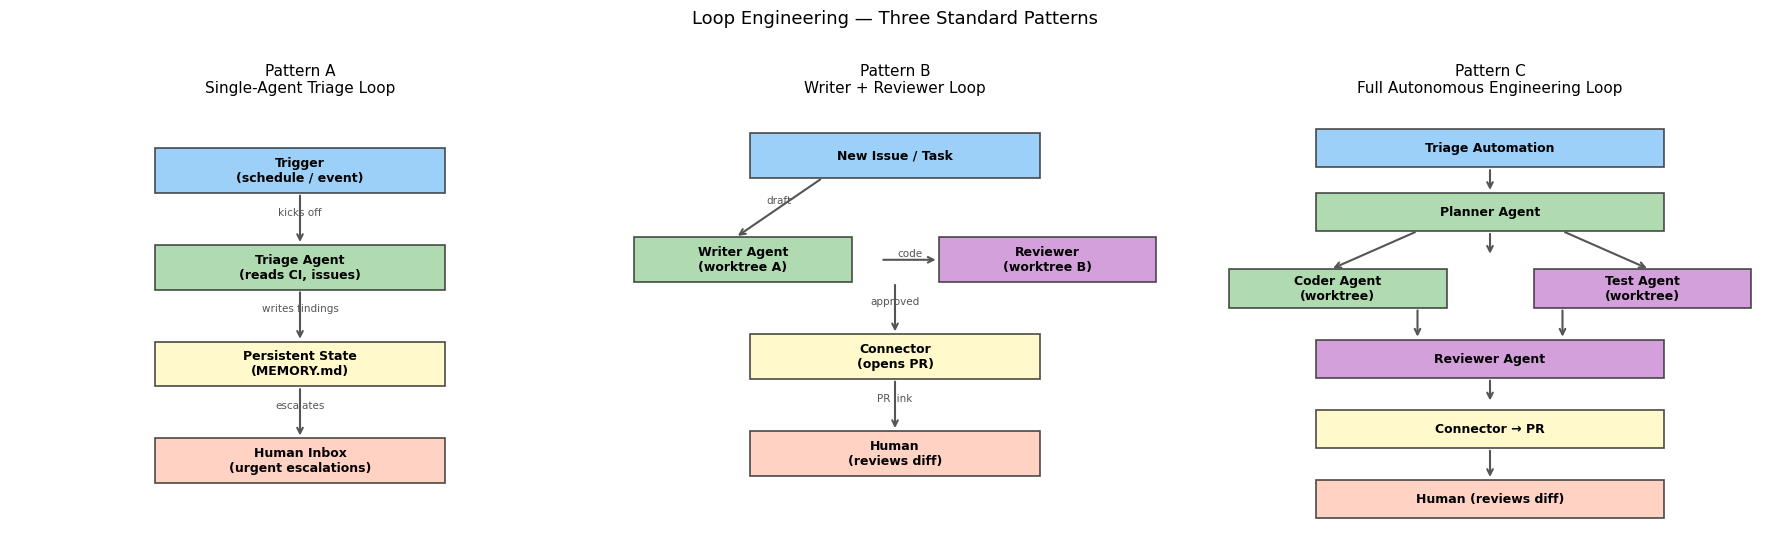

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

def draw_box(ax, x, y, w, h, label, color, fontsize=9):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='#333',
                          linewidth=1.2, zorder=2, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', zorder=3, wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=4)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.05, label, ha='center', fontsize=7.5, color=color)

colors = {'trigger': '#90CAF9', 'agent': '#A5D6A7', 'storage': '#FFF9C4',
          'human': '#FFCCBC', 'review': '#CE93D8'}

# ── Pattern A: Triage Loop ─────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('Pattern A\nSingle-Agent Triage Loop', fontsize=11, pad=8)
draw_box(ax, 1.0, 4.8, 2, 0.6, 'Trigger\n(schedule / event)', colors['trigger'])
draw_box(ax, 1.0, 3.5, 2, 0.6, 'Triage Agent\n(reads CI, issues)', colors['agent'])
draw_box(ax, 1.0, 2.2, 2, 0.6, 'Persistent State\n(MEMORY.md)', colors['storage'])
draw_box(ax, 1.0, 0.9, 2, 0.6, 'Human Inbox\n(urgent escalations)', colors['human'])
draw_arrow(ax, 2, 4.8, 2, 4.1, 'kicks off')
draw_arrow(ax, 2, 3.5, 2, 2.8, 'writes findings')
draw_arrow(ax, 2, 2.2, 2, 1.5, 'escalates')

# ── Pattern B: Writer + Reviewer ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('Pattern B\nWriter + Reviewer Loop', fontsize=11, pad=8)
draw_box(ax, 1.0, 5.0, 2, 0.6, 'New Issue / Task', colors['trigger'])
draw_box(ax, 0.2, 3.6, 1.5, 0.6, 'Writer Agent\n(worktree A)', colors['agent'])
draw_box(ax, 2.3, 3.6, 1.5, 0.6, 'Reviewer\n(worktree B)', colors['review'])
draw_box(ax, 1.0, 2.3, 2, 0.6, 'Connector\n(opens PR)', colors['storage'])
draw_box(ax, 1.0, 1.0, 2, 0.6, 'Human\n(reviews diff)', colors['human'])
draw_arrow(ax, 1.5, 5.0, 0.9, 4.2, 'draft')
draw_arrow(ax, 1.9, 3.9, 2.3, 3.9, 'code')
draw_arrow(ax, 2.0, 3.6, 2.0, 2.9, 'approved')
draw_arrow(ax, 2.0, 2.3, 2.0, 1.6, 'PR link')

# ── Pattern C: Full Loop ──────────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 4); ax.set_ylim(0, 7); ax.axis('off')
ax.set_title('Pattern C\nFull Autonomous Engineering Loop', fontsize=11, pad=8)
draw_box(ax, 0.8, 6.0, 2.4, 0.6, 'Triage Automation', colors['trigger'])
draw_box(ax, 0.8, 5.0, 2.4, 0.6, 'Planner Agent', colors['agent'])
draw_box(ax, 0.2, 3.8, 1.5, 0.6, 'Coder Agent\n(worktree)', colors['agent'])
draw_box(ax, 2.3, 3.8, 1.5, 0.6, 'Test Agent\n(worktree)', colors['review'])
draw_box(ax, 0.8, 2.7, 2.4, 0.6, 'Reviewer Agent', colors['review'])
draw_box(ax, 0.8, 1.6, 2.4, 0.6, 'Connector → PR', colors['storage'])
draw_box(ax, 0.8, 0.5, 2.4, 0.6, 'Human (reviews diff)', colors['human'])
for y1, y2 in [(6.0, 5.6), (5.0, 4.6), (2.7, 2.3), (1.6, 1.1)]:
    draw_arrow(ax, 2.0, y1, 2.0, y2)
draw_arrow(ax, 1.5, 5.0, 0.9, 4.4)
draw_arrow(ax, 2.5, 5.0, 3.1, 4.4)
draw_arrow(ax, 1.5, 3.8, 1.5, 3.3)
draw_arrow(ax, 2.5, 3.8, 2.5, 3.3)

plt.suptitle('Loop Engineering — Three Standard Patterns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 8. Takeaways — What to Build First

The three failure modes that kill loops before they deliver value:

| Failure | Symptom | Fix |
|---|---|---|
| **No exit condition** | Loop runs forever, burns budget | Every goal needs a stop condition |
| **No worktrees** | Agents corrupt each other's files | One branch per task, always |
| **No escalation path** | Errors silently accumulate | Every failure state must notify a human |

### Implementation order (maximum value → minimum risk)

```
Week 1: Write one SKILL.md for your main project
Week 2: Add a daily /goal for CI triage
Week 3: Add a GitHub MCP connector (agents can open PRs)
Week 4: Add a reviewer sub-agent to catch oversights
Week 5: Wire it all together with LoopMemory state
```

### The engineer's responsibility in a loop

The loop handles **execution**. You handle **judgment**:
- Approve/reject every PR the loop creates
- Review the loop's audit log weekly
- Keep skills up-to-date as conventions evolve
- Maintain comprehension: if you can't explain the last 10 commits, slow the loop down

> "Build the loop. But build it like someone who intends to stay the engineer,
> not just the person who presses go." — Addy Osmani
